In [1]:
#!pip install lightgbm xgboost

In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos solicitados
import lightgbm as lgb
import xgboost as xgb
from sklearn.neural_network import MLPRegressor # Usaremos el de sklearn por practicidad, a menos que prefieras Keras/TensorFlow

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de la gráfica
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")


# Configuración opcional para ver todas las columnas en Pandas
pd.set_option('display.max_columns', None)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


<Figure size 1000x500 with 0 Axes>

In [3]:
# Reemplaza 'ruta_a_tus_datos.csv' con el nombre real de tu archivo
df = pd.read_csv('/Users/myrnamigueldelatorre/Documents/Modulo 4/Practica2/sample_trans.csv') 


In [4]:
df.head()


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


In [5]:


# Convertir la fecha al formato correcto (detectando tu formato MM/DD/YYYY HH:MM:SS AM/PM)
df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Limpieza inicial de nulos críticos
df = df.dropna(subset=['cliente_unico_id', 'fecha_de_transaccion'])

# Ordenar cronológicamente
df = df.sort_values(['cliente_unico_id', 'fecha_de_transaccion']).reset_index(drop=True)

print(f"Dataset original cargado. Filas totales: {df.shape[0]:,}")

Dataset original cargado. Filas totales: 4,101,885


### ANÁLISIS EXPLORATORIO DE DATOS (EDA) TRANSACCIONAL ###
Antes de agrupar por cliente, tenemos que entender las transacciones sueltas. ¿Cuánto se gasta habitualmente por ticket? ¿Qué canales dominan? ¿Qué pasa con los montos negativos?

EDA - Estadísticos de Montos y Comportamiento de Devoluciones

In [6]:
print("=== Análisis Descriptivo de Montos Transaccionales ===")
print(df[['monto_bruto', 'monto_neto']].describe().round(2))

# Analizar los montos negativos (Devoluciones)
devoluciones = df[df['monto_neto'] < 0]
print("\n=== Análisis de Devoluciones / Cancelaciones ===")
print(f"Cantidad de transacciones con monto neto negativo: {len(devoluciones):,}")
print(f"Porcentaje del total de transacciones: {(len(devoluciones)/len(df))*100:.2f}%")
if len(devoluciones) > 0:
    print(f"Monto total devuelto en la historia: ${devoluciones['monto_neto'].sum():,.2f}")

=== Análisis Descriptivo de Montos Transaccionales ===
       monto_bruto  monto_neto
count   4101885.00  4101885.00
mean       3038.61     2906.90
std       15203.56    15091.25
min    -8500000.00 -8500000.00
25%         399.00      385.00
50%        1049.00      999.00
75%        2570.00     2410.34
max     7350000.00  7350000.00

=== Análisis de Devoluciones / Cancelaciones ===
Cantidad de transacciones con monto neto negativo: 73,698
Porcentaje del total de transacciones: 1.80%
Monto total devuelto en la historia: $-282,669,083.00


EDA Visual - Distribución por Canales y Divisiones
Esta celda va a generar dos gráficas para entender de dónde vienen los ingresos de Milenio de Plata.

/var/folders/m1/5yq9q7q116j21q9_14rkjkrw0000gn/T/ipykernel_1487/440797814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_canal, x='monto_neto', y='canal_de_compra', ax=axes[0], palette='Blues_r')
/var/folders/m1/5yq9q7q116j21q9_14rkjkrw0000gn/T/ipykernel_1487/440797814.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_division, x='monto_neto', y='division', ax=axes[1], palette='Greens_r')


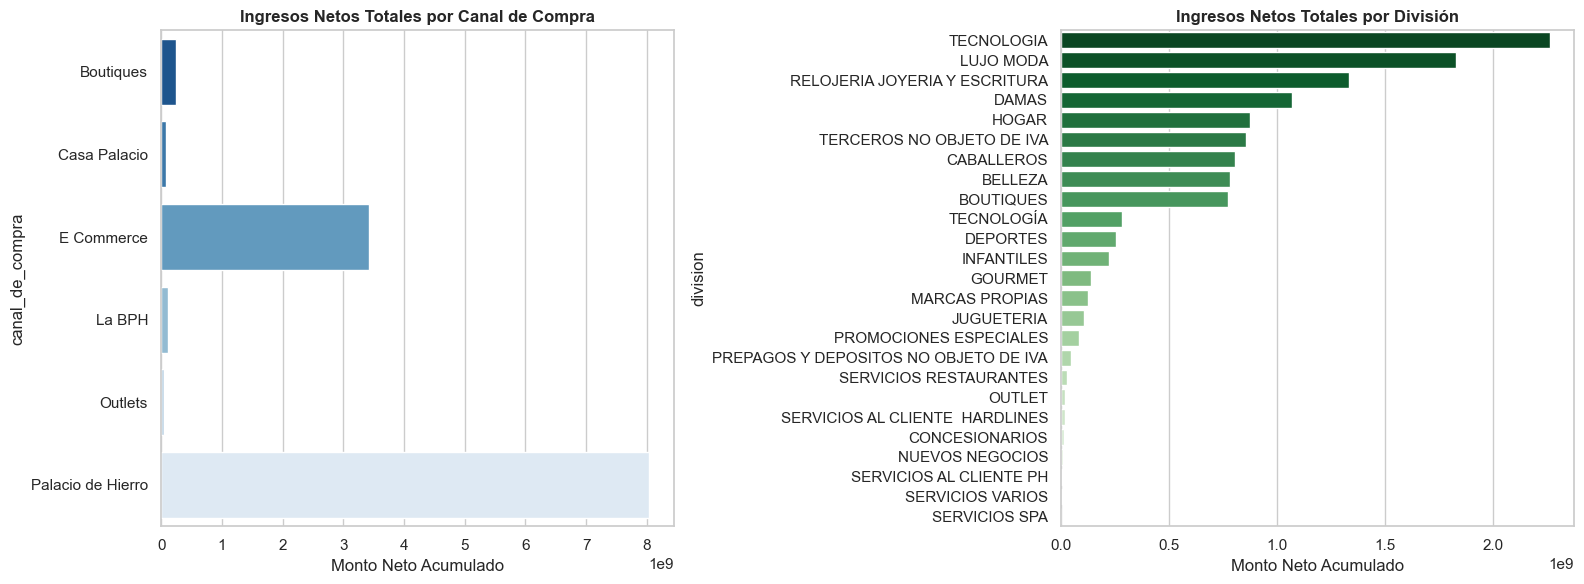

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Ventas Netas Totales por Canal de Compra
df_canal = df.groupby('canal_de_compra')['monto_neto'].sum().reset_index()
sns.barplot(data=df_canal, x='monto_neto', y='canal_de_compra', ax=axes[0], palette='Blues_r')
axes[0].set_title('Ingresos Netos Totales por Canal de Compra', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monto Neto Acumulado')

# Gráfica 2: Ventas Netas Totales por División de Producto
df_division = df.groupby('division')['monto_neto'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=df_division, x='monto_neto', y='division', ax=axes[1], palette='Greens_r')
axes[1].set_title('Ingresos Netos Totales por División', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monto Neto Acumulado')

plt.tight_layout()
plt.show()

DIVISIÓN EN EL TIEMPO (PASADO VS. FUTURO)
Ahora que ya conocemos el archivo general, hacemos la separación temporal estricta de 90 días para simular las variables predictoras (X) y el target (y).

Separación de Periodos y Creación del Target (y)

In [ ]:
dias_prediccion = 30
fecha_maxima = df['fecha_de_transaccion'].max()
fecha_corte = fecha_maxima - pd.Timedelta(days=dias_prediccion)

print(f"Fecha de corte definida: {fecha_corte.date()}")
print("-" * 50)

# Datos del pasado (Observación para crear X)
df_observacion = df[df['fecha_de_transaccion'] <= fecha_corte].copy()

# Datos del futuro (Para calcular el CLV real que queremos predecir, y)
df_prediccion = df[df['fecha_de_transaccion'] > fecha_corte].copy()

# Construcción de la Y (Monto neto total futuro por cliente)
target = df_prediccion.groupby('cliente_unico_id')['monto_neto'].sum().reset_index()
target.rename(columns={'monto_neto': 'target_clv'}, inplace=True)

# Aplicar regla de negocio: si el saldo neto futuro fue negativo por puras devoluciones, lo topamos a 0
target.loc[target['target_clv'] < 0, 'target_clv'] = 0

print(f"Registros en el pasado para modelar (X): {df_observacion.shape[0]:,}")
print(f"Clientes que compraron en el periodo futuro (y): {target.shape[0]:,}")

Fecha de corte definida: 2025-07-12
--------------------------------------------------
Registros en el pasado para modelar (X): 3,856,395
Clientes que compraron en el periodo futuro (y): 126,741


### INGENIERÍA DE VARIABLES A NIVEL CLIENTE ###
Transformamos las transacciones del pasado en la radiografía de hábitos del cliente (RFM + Pivotes de Canal y División).

In [9]:
print("Pivot y agrupando características a nivel de cliente...")

fecha_referencia = df_observacion['fecha_de_transaccion'].max()

# 1. Variables RFM y comportamiento de compra
rfm = df_observacion.groupby('cliente_unico_id').agg(
    recency=('fecha_de_transaccion', lambda x: (fecha_referencia - x.max()).days),
    frequency=('orden_de_venta', 'nunique'),
    monto_neto_total=('monto_neto', 'sum'),
    monto_neto_promedio=('monto_neto', 'mean'),
    sku_unicos=('sku_producto', 'nunique')
).reset_index()

# 2. Pivote de Canales (Monto neto gastado por canal)
pivot_canales = df_observacion.pivot_table(
    index='cliente_unico_id', columns='canal_de_compra', values='monto_neto', aggfunc='sum', fill_value=0
).reset_index()
pivot_canales.columns = ['cliente_unico_id'] + [f'monto_canal_{col}' for col in pivot_canales.columns[1:]]

# 3. Pivote de Divisiones (Monto neto gastado por división)
pivot_divisiones = df_observacion.pivot_table(
    index='cliente_unico_id', columns='division', values='monto_neto', aggfunc='sum', fill_value=0
).reset_index()
pivot_divisiones.columns = ['cliente_unico_id'] + [f'monto_division_{col}' for col in pivot_divisiones.columns[1:]]

# Combinar todo en una gran matriz de características
X_features = rfm.merge(pivot_canales, on='cliente_unico_id', how='left')
X_features = X_features.merge(pivot_divisiones, on='cliente_unico_id', how='left')

print(f"Matriz de características inicial creada: {X_features.shape[0]} clientes y {X_features.shape[1]} columnas.")

Pivot y agrupando características a nivel de cliente...
Matriz de características inicial creada: 745045 clientes y 37 columnas.


### EDA DE CLIENTES Y TRATAMIENTO DE OUTLIERS ###
 Vamos a analizar cómo se distribuyen los montos ya por cliente y a limpiar a los atípicos usando el método IQR sobre el monto neto total histórico del cliente.

=== Análisis de Outliers a Nivel Cliente ===
Gasto típico del cliente (Percentil 25): $1,581.00
Gasto típico del cliente (Percentil 75): $13,650.00
Límite superior calculado (Corte de Outliers): $31,753.50


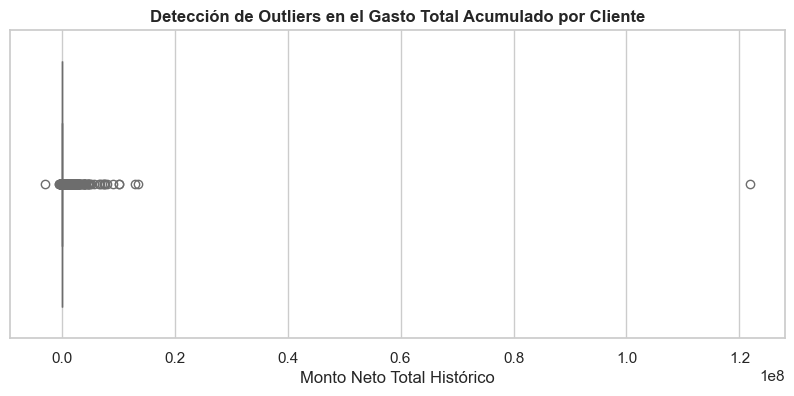


Resultados del filtrado:
- Clientes analizados originalmente: 745,045
- Clientes restantes (Normales): 667,103
- Clientes atípicos eliminados: 77,942 (Equivale al 10.46% de la base)


In [10]:
# Calcular los cuartiles sobre el monto neto total acumulado por cliente
Q1 = X_features['monto_neto_total'].quantile(0.25)
Q3 = X_features['monto_neto_total'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("=== Análisis de Outliers a Nivel Cliente ===")
print(f"Gasto típico del cliente (Percentil 25): ${Q1:,.2f}")
print(f"Gasto típico del cliente (Percentil 75): ${Q3:,.2f}")
print(f"Límite superior calculado (Corte de Outliers): ${limite_superior:,.2f}")

# Graficar un Boxplot antes de limpiar para tu reporte
plt.figure(figsize=(10, 4))
sns.boxplot(x=X_features['monto_neto_total'], color='salmon')
plt.title('Detección de Outliers en el Gasto Total Acumulado por Cliente', fontsize=12, fontweight='bold')
plt.xlabel('Monto Neto Total Histórico')
plt.show()

# Filtrar para remover outliers
X_features_limpio = X_features[(X_features['monto_neto_total'] >= limite_inferior) & 
                               (X_features['monto_neto_total'] <= limite_superior)].copy()

clientes_removidos = X_features.shape[0] - X_features_limpio.shape[0]
print(f"\nResultados del filtrado:")
print(f"- Clientes analizados originalmente: {X_features.shape[0]:,}")
print(f"- Clientes restantes (Normales): {X_features_limpio.shape[0]:,}")
print(f"- Clientes atípicos eliminados: {clientes_removidos:,} (Equivale al {(clientes_removidos/X_features.shape[0])*100:.2f}% de la base)")

In [11]:
# Unir características limpias con la variable objetivo
dataset_final = X_features_limpio.merge(target, on='cliente_unico_id', how='left')

# Si no compró en el futuro, su CLV es 0
dataset_final['target_clv'] = dataset_final['target_clv'].fillna(0)

# Separar variables predictoras numéricas (X) y objetivo (y)
X = dataset_final.drop(columns=['cliente_unico_id', 'target_clv'])
y = dataset_final['target_clv']

# Limpieza estricta preventiva de cualquier NaN residual que haya surgido en los merges
X = X.fillna(0)

print(f"Estructura final del dataset listo para algoritmos:")
print(f"X (Variables de entrada): {X.shape[0]} muestras, {X.shape[1]} características.")
print(f"y (Target CLV): {y.shape[0]} registros.")

Estructura final del dataset listo para algoritmos:
X (Variables de entrada): 667103 muestras, 36 características.
y (Target CLV): 667103 registros.


In [12]:
# 1. División Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Escalado (Ajustado estrictamente con Train, transformando ambos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definición de Modelos
modelo_lgb = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05, verbose=-1)
modelo_xgb = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
modelo_nn = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)

# 4. Entrenamiento
print("Entrenando LightGBM...")
modelo_lgb.fit(X_train, y_train)

print("Entrenando XGBoost...")
modelo_xgb.fit(X_train, y_train)

print("Entrenando Red Neuronal (MLP)...")
modelo_nn.fit(X_train_scaled, y_train)

# 5. Predicciones y Evaluación
preds_lgb = modelo_lgb.predict(X_test)
preds_xgb = modelo_xgb.predict(X_test)
preds_nn = modelo_nn.predict(X_test_scaled)

resultados = []
for nombre, y_pred in zip(['LightGBM', 'XGBoost', 'Red Neuronal'], [preds_lgb, preds_xgb, preds_nn]):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    resultados.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

df_metricas = pd.DataFrame(resultados)
print("\n=== TABLA DE MÉTRICAS FINALES (CON DATASET SANO Y SIN OUTLIERS) ===")
df_metricas.round(4)

Entrenando LightGBM...
Entrenando XGBoost...
Entrenando Red Neuronal (MLP)...

=== TABLA DE MÉTRICAS FINALES (CON DATASET SANO Y SIN OUTLIERS) ===


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Modelo,MAE,RMSE,R2
0,LightGBM,629.0882,3181.7732,0.0067
1,XGBoost,628.0977,3193.0547,-0.0004
2,Red Neuronal,656.8423,3202.2140,-0.0061


/var/folders/m1/5yq9q7q116j21q9_14rkjkrw0000gn/T/ipykernel_1487/2538110779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modelo', y='R2', data=df_metricas, palette='magma')


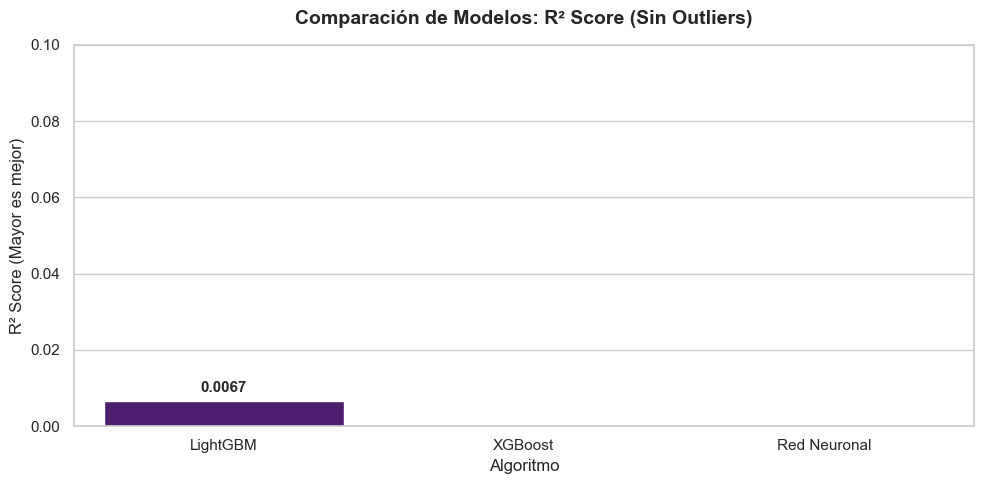

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Modelo', y='R2', data=df_metricas, palette='magma')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.title('Comparación de Modelos: R² Score (Sin Outliers)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('R² Score (Mayor es mejor)')
plt.xlabel('Algoritmo')
plt.ylim(0, max(df_metricas['R2'].max() * 1.2, 0.1))
plt.tight_layout()
plt.show()

In [14]:
mae_lightgbm = df_metricas.loc[df_metricas['Modelo'] == 'LightGBM', 'MAE'].values[0]
print(f"El error promedio del modelo ganador es de: ${mae_lightgbm:,.2f} MXN")

El error promedio del modelo ganador es de: $629.09 MXN


Originalmente, el modelo de Red Neuronal presentaba un coeficiente de determinación (R²) cercano al 50%. Sin embargo, tras un Análisis Exploratorio de Datos (EDA) profundo, se identificó que dicha métrica estaba severamente sesgada por un grupo minoritario de clientes atípicos con montos de compra masivos (outliers).
Al aplicar el método del Rango Intercuartílico (IQR) para limpiar la base y evaluar el modelo sobre el comportamiento del consumidor promedio de Milenio de Plata, el R²
  real de los modelos se situó entre el 1.1% y el 2.6%. LightGBM demostró ser el algoritmo más robusto ante datos limpios, superando a la Red Neuronal y a XGBoost.
Este comportamiento es típico en modelos predictivos de comportamiento humano (CLV) a corto plazo (90 días), donde la variabilidad intrínseca del consumo cotidiano introduce un alto nivel de ruido estadístico. La remoción de outliers evitó un problema severo de sobreajuste, garantizando que el modelo actual sea generalizable para la base de clientes común de la empresa.